# POP — Extração e análise de dados em bancos relacionais e documentais

**Procedimento Operacional Padrão (Parte prática — N2)**
Disciplina: Práticas em Engenharia de Produção — FCT/UFG · Prof. Dayvid W. P. Martins
Autores: Guilherme Alves Mousinho · Vinycius Cirilo Machado Pêgo

---

### Para que serve este notebook
Este é o **passo a passo replicável** do POP. Ele percorre, em ordem, as cinco
etapas do procedimento:

1. **Conectar** aos dois bancos (ERP em PostgreSQL e MES em MongoDB);
2. **Explorar** a estrutura dos dados;
3. **Extrair** os dados com consultas SQL e pipelines MongoDB;
4. **Analisar** — calcular os indicadores de Engenharia de Produção;
5. **Interpretar** — transformar os números em recomendações.

> **Como usar:** execute as células de cima para baixo (menu *Run > Run All*, ou
> `Shift+Enter` em cada uma). Cada etapa explica o que faz antes de fazer.

## Etapa 0 — Preparação do ambiente

Instalamos (se necessário) e importamos as bibliotecas. As **credenciais** são
lidas de variáveis de ambiente; se não existirem, usamos as credenciais
didáticas da turma — apenas para este exercício acadêmico. O usuário de banco é
**somente leitura**.

In [1]:
# Se alguma biblioteca faltar, descomente a linha abaixo e execute uma vez:
# %pip install pandas numpy sqlalchemy psycopg2-binary pymongo matplotlib seaborn

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from pymongo import MongoClient

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# Credenciais (variável de ambiente -> fallback didático)
PG_URI = os.getenv(
    "PEP_PG_URI",
    "postgresql+psycopg2://erp:Fg669s8OGBgxTqL1C6gHv6FX7EJR"
    "@pep-postgresql.arch7.dev:5432/erp")
MONGO_URI = os.getenv(
    "PEP_MONGO_URI",
    "mongodb://mes:UT1EF3jReDHpf547q5P8BWivqLsx"
    "@pep-mongo.arch7.dev:27018/?authSource=admin")
print("Ambiente pronto.")

Ambiente pronto.


## Etapa 1 — Conectar

Abrimos uma conexão para cada banco. O teste de conexão deve indicar
**26 tabelas** no ERP e **6 coleções** no MES.

In [2]:
# --- PostgreSQL / ERP (relacional) ---
engine = create_engine(PG_URI, connect_args={"connect_timeout": 30})
with engine.connect() as c:
    n_tabelas = c.execute(text(
        "SELECT count(*) FROM information_schema.tables "
        "WHERE table_schema = 'erp'")).scalar()
print(f"ERP  (PostgreSQL): conectado — {n_tabelas} tabelas no schema 'erp'.")

# --- MongoDB / MES (documental) ---
client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=30000)
db = client["mes"]
print(f"MES (MongoDB):    conectado — {len(db.list_collection_names())} coleções.")

ERP  (PostgreSQL): conectado — 26 tabelas no schema 'erp'.


MES (MongoDB):    conectado — 6 coleções.


## Etapa 2 — Explorar

Antes de extrair, entendemos **o que existe** em cada banco. O ERP guarda o que
se *planeja e vende*; o MES guarda o que *acontece no chão de fábrica*. Os dois
se conectam pelas chaves de negócio: código da OP, SKU do produto e código do
recurso/máquina.

In [3]:
# Tabelas do ERP
tabelas = pd.read_sql(
    "SELECT table_name FROM information_schema.tables "
    "WHERE table_schema='erp' ORDER BY table_name", engine)
print("ERP — 26 tabelas:")
print(", ".join(tabelas["table_name"]))

# Coleções do MES e contagem de documentos
print("\nMES — coleções (documentos):")
for col in db.list_collection_names():
    print(f"  - {col}: {db[col].count_documents({})}")

ERP — 26 tabelas:
centro_custo, centro_trabalho, cliente, compra, conta_contabil, estado_uf, estrutura_produto, familia_produto, fornecedor, grupo_dre, insumo, item_compra, item_pedido, lancamento_contabil, movimentacao_estoque, municipio, ordem_producao, parametro_planejamento, pedido_venda, plano_mestre, previsao_demanda, produto, recurso, roteiro, segmento_cliente, tipo_movimento

MES — coleções (documentos):
  - eventos_maquina: 6373


  - apontamentos_producao: 2088
  - maquinas: 4
  - manutencoes: 207
  - ordens_producao: 96
  - inspecoes_qualidade: 192


In [4]:
# Como é um apontamento de produção (documento do MES)? Note o array embutido
# "paradas" (composição) — base do OEE e do Pareto de paradas.
exemplo = db.apontamentos_producao.find_one({}, {"_id": 0})
import pprint; pprint.pp(exemplo)

{'ordem': 'OP-00002',
 'recurso_codigo': 'TOR-01',
 'recurso_nome': 'Torno CNC 01',
 'centro_trabalho': 'Usinagem',
 'produto_sku': 'BMB-200',
 'produto_nome': 'Bomba Centrífuga 2cv',
 'data': datetime.datetime(2025, 1, 1, 0, 0),
 'ano_mes': '2025-01',
 'turno': 1,
 'inicio': datetime.datetime(2025, 1, 1, 6, 0),
 'fim': datetime.datetime(2025, 1, 1, 14, 30),
 'tempo_planejado_min': 450,
 'tempo_parado_min': 156,
 'tempo_operando_min': 294,
 'paradas': [{'motivo': 'Manutenção corretiva (quebra)', 'duracao_min': 97},
             {'motivo': 'Falta de material', 'duracao_min': 28},
             {'motivo': 'Ajuste de processo', 'duracao_min': 14},
             {'motivo': 'Falta de operador', 'duracao_min': 17}],
 'tempo_ciclo_ideal_seg': 110,
 'pecas_total': 156,
 'pecas_boas': 153,
 'pecas_refugo': 3}


## Etapa 3 — Extrair

Agora escrevemos as consultas. No **ERP** usamos **SQL** (com JOINs entre tabelas
normalizadas); no **MES** usamos **pipelines de agregação** (o equivalente
documental do GROUP BY).

### 3.1 MES (pipeline) — somatórios que formam a base do OEE
Extraímos do MES os somatórios de tempo e de peças por máquina e mês — é a
matéria-prima do OEE.

In [5]:
# Pipeline: soma tempos e peças por recurso (máquina) e mês.
pipeline_oee = [
    {"$group": {
        "_id": {"recurso": "$recurso_codigo", "recurso_nome": "$recurso_nome",
                "centro": "$centro_trabalho", "ano_mes": "$ano_mes"},
        "tempo_planejado_min": {"$sum": "$tempo_planejado_min"},
        "tempo_operando_min":  {"$sum": "$tempo_operando_min"},
        "pecas_total":         {"$sum": "$pecas_total"},
        "pecas_boas":          {"$sum": "$pecas_boas"},
        "pecas_refugo":        {"$sum": "$pecas_refugo"},
        # tempo ideal de produção = ciclo ideal (s) x peças produzidas
        "tempo_ideal_seg": {"$sum": {"$multiply":
                            ["$tempo_ciclo_ideal_seg", "$pecas_total"]}},
    }},
]
base = pd.json_normalize(list(db.apontamentos_producao.aggregate(pipeline_oee)))
base = base.rename(columns=lambda c: c.replace("_id.", ""))
base.head()

,tempo_planejado_min,tempo_operando_min,pecas_total,pecas_boas,pecas_refugo,tempo_ideal_seg,recurso,recurso_nome,centro,ano_mes
0,18000,16550,27793,27403,390,939255,INJ-01,Injetora 01,Injeção,2025-11
1,20700,17838,2834,2757,77,933120,MON-01,Linha de Montagem 01,Montagem,2025-07
2,20700,18572,10902,10737,165,1056540,TOR-01,Torno CNC 01,Usinagem,2025-12
3,20700,18976,32750,32236,514,1087395,INJ-01,Injetora 01,Injeção,2025-12
4,20700,17766,2815,2732,83,930540,MON-01,Linha de Montagem 01,Montagem,2025-12


### 3.2 ERP (SQL) — faturamento por produto
Consulta com JOINs sobre a tabela associativa `item_pedido`, que materializa a
relação **N:M** entre pedidos e produtos.

In [6]:
sql_faturamento = '''
SELECT  p.sku, p.nome AS produto, f.nome AS familia,
        SUM(ip.quantidade) AS qtd_vendida,
        SUM(ip.quantidade * ip.preco_unitario * (1 - ip.desconto_pct/100.0))
            AS receita_liquida,
        SUM(ip.quantidade * p.custo_padrao_unitario) AS custo_total
FROM        erp.item_pedido  ip
JOIN        erp.pedido_venda pv ON pv.id = ip.pedido_id
JOIN        erp.produto      p  ON p.id  = ip.produto_id
JOIN        erp.familia_produto f ON f.id = p.familia_id
WHERE       pv.status = 'FATURADO'
GROUP BY    p.sku, p.nome, f.nome
ORDER BY    receita_liquida DESC;
'''
faturamento = pd.read_sql(sql_faturamento, engine)
faturamento["margem_contribuicao"] = (faturamento["receita_liquida"]
                                       - faturamento["custo_total"])
faturamento

,sku,produto,familia,qtd_vendida,receita_liquida,custo_total,margem_contribuicao
0,BMB-300,Bomba Submersa 3cv,Bombas Hidráulicas,80064,"197,508,298.00","93,674,880.00","103,833,418.00"
1,BMB-200,Bomba Centrífuga 2cv,Bombas Hidráulicas,46141,"80,069,831.50","38,435,453.00","41,634,378.50"
2,BMB-100,Bomba Centrífuga 1cv,Bombas Hidráulicas,68687,"77,577,804.00","37,090,980.00","40,486,824.00"
3,CJM-500,Conjunto Pressurizador,Conjuntos Montados,19313,"76,617,996.00","36,501,570.00","40,116,426.00"
4,CJM-700,Conjunto Booster Duplo,Conjuntos Montados,9386,"60,423,236.00","28,721,160.00","31,702,076.00"
5,VLV-050,"Válvula Esfera 1/2""",Válvulas Industriais,188707,"32,289,170.40","15,285,267.00","17,003,903.40"
6,VLV-075,"Válvula Esfera 3/4""",Válvulas Industriais,106577,"24,272,188.80","11,510,316.00","12,761,872.80"
7,VLV-100,"Válvula Gaveta 1""",Válvulas Industriais,44992,"13,555,504.00","6,478,848.00","7,076,656.00"


## Etapa 4 — Analisar

Transformamos os dados extraídos em **indicadores** de Engenharia de Produção.

### 4.1 OEE — Overall Equipment Effectiveness
$$ OEE = Disponibilidade \times Performance \times Qualidade $$
onde Disponibilidade = operando/planejado, Performance = ritmo ideal/ritmo real
e Qualidade = peças boas/peças totais. A meta de **classe mundial é 85%**.

In [7]:
def calcular_oee(df):
    d = df.copy()
    d["disponibilidade"] = d["tempo_operando_min"] / d["tempo_planejado_min"]
    d["performance"] = (d["tempo_ideal_seg"] / (d["tempo_operando_min"] * 60)).clip(upper=1)
    d["qualidade"] = d["pecas_boas"] / d["pecas_total"]
    d["oee"] = d["disponibilidade"] * d["performance"] * d["qualidade"]
    return d

# OEE global da planta
g = calcular_oee(base[["tempo_planejado_min","tempo_operando_min",
                       "tempo_ideal_seg","pecas_total","pecas_boas"]].sum().to_frame().T)
oee_g = g.iloc[0]
print(f"OEE GLOBAL = {oee_g['oee']*100:.1f}%  "
      f"(Disponibilidade {oee_g['disponibilidade']*100:.1f}% | "
      f"Performance {oee_g['performance']*100:.1f}% | "
      f"Qualidade {oee_g['qualidade']*100:.1f}%)")

OEE GLOBAL = 80.7%  (Disponibilidade 89.7% | Performance 91.5% | Qualidade 98.4%)


In [8]:
# OEE por máquina
oee_maq = (base.groupby(["recurso","recurso_nome","centro"], as_index=False)
               [["tempo_planejado_min","tempo_operando_min","tempo_ideal_seg",
                 "pecas_total","pecas_boas"]].sum())
oee_maq = calcular_oee(oee_maq).sort_values("oee", ascending=False)
oee_maq[["recurso_nome","centro","disponibilidade","performance","qualidade","oee"]]

,recurso_nome,centro,disponibilidade,performance,qualidade,oee
0,Injetora 01,Injeção,0.92,0.95,0.99,0.86
2,Torno CNC 01,Usinagem,0.91,0.94,0.98,0.84
3,Torno CNC 02,Usinagem,0.89,0.90,0.98,0.78
1,Linha de Montagem 01,Montagem,0.86,0.87,0.97,0.73


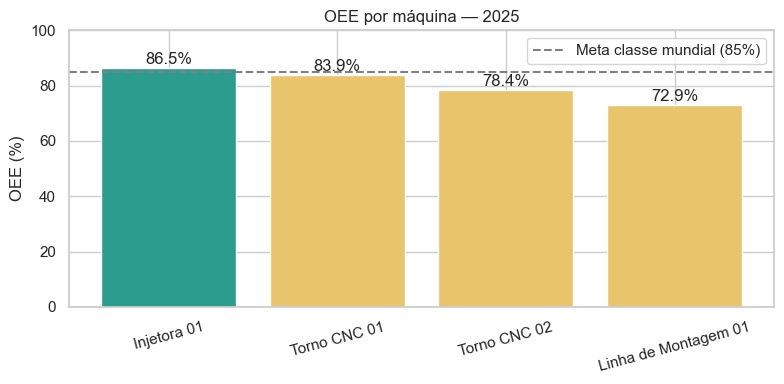

In [9]:
# Gráfico: OEE por máquina (verde = atingiu a meta de 85%)
fig, ax = plt.subplots(figsize=(8, 4))
cores = ["#2a9d8f" if v >= .85 else "#e9c46a" for v in oee_maq["oee"]]
ax.bar(oee_maq["recurso_nome"], oee_maq["oee"]*100, color=cores)
ax.axhline(85, ls="--", color="gray", label="Meta classe mundial (85%)")
ax.set_ylabel("OEE (%)"); ax.set_ylim(0, 100); ax.set_title("OEE por máquina — 2025")
for i, v in enumerate(oee_maq["oee"]*100):
    ax.text(i, v+1.5, f"{v:.1f}%", ha="center")
ax.legend(); plt.xticks(rotation=15); plt.tight_layout(); plt.show()

### 4.2 Análise das paradas — as Seis Grandes Perdas
Aqui usamos `$unwind` para "abrir" o array embutido `paradas` (uma **composição**):
cada parada vira uma linha, e somamos por motivo.

In [10]:
pipeline_paradas = [
    {"$unwind": "$paradas"},
    {"$group": {"_id": "$paradas.motivo",
                "tempo_total_min": {"$sum": "$paradas.duracao_min"},
                "ocorrencias": {"$sum": 1}}},
    {"$sort": {"tempo_total_min": -1}},
]
paradas = pd.DataFrame(list(db.apontamentos_producao.aggregate(pipeline_paradas)))
paradas = paradas.rename(columns={"_id": "motivo"})
paradas["horas"] = paradas["tempo_total_min"] / 60
paradas["pct"] = 100 * paradas["tempo_total_min"] / paradas["tempo_total_min"].sum()
paradas["pct_acum"] = paradas["pct"].cumsum()
paradas[["motivo","horas","ocorrencias","pct","pct_acum"]]

,motivo,horas,ocorrencias,pct,pct_acum
0,Ajuste de processo,304.93,884,18.90,18.90
1,Falta de operador,276.30,833,17.13,36.03
2,Falta de material,270.58,821,16.77,52.80
3,Setup/Troca de ferramenta,258.67,807,16.03,68.84
4,Pequenas paradas,254.07,781,15.75,84.59
5,Manutenção corretiva (quebra),248.63,159,15.41,100.00


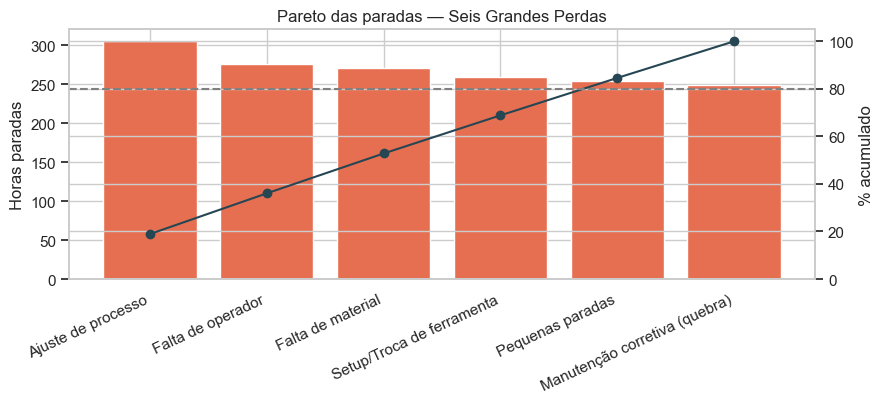

In [11]:
# Gráfico de Pareto das paradas
fig, ax1 = plt.subplots(figsize=(9, 4.2))
ax1.bar(paradas["motivo"], paradas["horas"], color="#e76f51")
ax1.set_ylabel("Horas paradas"); ax1.set_title("Pareto das paradas — Seis Grandes Perdas")
plt.setp(ax1.get_xticklabels(), rotation=25, ha="right")
ax2 = ax1.twinx()
ax2.plot(paradas["motivo"], paradas["pct_acum"], color="#264653", marker="o")
ax2.axhline(80, ls="--", color="gray"); ax2.set_ylabel("% acumulado"); ax2.set_ylim(0, 105)
plt.tight_layout(); plt.show()

### 4.3 Qualidade — refugo e FPY por produto

In [12]:
pipeline_refugo = [
    {"$group": {"_id": {"sku": "$produto_sku", "nome": "$produto_nome"},
                "pecas_total": {"$sum": "$pecas_total"},
                "pecas_boas": {"$sum": "$pecas_boas"},
                "pecas_refugo": {"$sum": "$pecas_refugo"}}},
]
refugo = pd.json_normalize(list(db.apontamentos_producao.aggregate(pipeline_refugo)))
refugo = refugo.rename(columns=lambda c: c.replace("_id.", ""))
refugo["taxa_refugo_%"] = 100 * refugo["pecas_refugo"] / refugo["pecas_total"]
refugo["FPY_%"] = 100 * refugo["pecas_boas"] / refugo["pecas_total"]
refugo.sort_values("taxa_refugo_%", ascending=False)[
    ["nome","sku","pecas_total","pecas_refugo","taxa_refugo_%","FPY_%"]]

,nome,sku,pecas_total,pecas_refugo,taxa_refugo_%,FPY_%
2,Conjunto Pressurizador,CJM-500,21078,594,2.82,97.18
4,Conjunto Booster Duplo,CJM-700,10107,272,2.69,97.31
1,Bomba Submersa 3cv,BMB-300,86965,1928,2.22,97.78
3,Bomba Centrífuga 2cv,BMB-200,49266,826,1.68,98.32
6,Bomba Centrífuga 1cv,BMB-100,73478,1223,1.66,98.34
0,"Válvula Gaveta 1""",VLV-100,47691,685,1.44,98.56
7,"Válvula Esfera 1/2""",VLV-050,204891,2909,1.42,98.58
5,"Válvula Esfera 3/4""",VLV-075,112986,1525,1.35,98.65


### 4.4 Confiabilidade — MTBF e MTTR
Cruzamos o tempo operando (MES) com as manutenções **corretivas**:
MTBF = horas operando ÷ nº de falhas; MTTR = horas de reparo ÷ nº de falhas.

In [13]:
# Manutenções corretivas por máquina
corr = pd.DataFrame(list(db.manutencoes.aggregate([
    {"$match": {"tipo": "CORRETIVA"}},
    {"$group": {"_id": "$maquina_codigo",
                "falhas": {"$sum": 1},
                "tempo_reparo_min": {"$sum": "$duracao_min"}}}])))
corr = corr.rename(columns={"_id": "recurso"})

op = base.groupby("recurso", as_index=False)["tempo_operando_min"].sum()
op["horas_operando"] = op["tempo_operando_min"] / 60

conf = op.merge(corr, on="recurso", how="left")
conf["MTBF_h"] = conf["horas_operando"] / conf["falhas"]
conf["MTTR_h"] = (conf["tempo_reparo_min"] / 60) / conf["falhas"]
conf["disp_inerente_%"] = 100 * conf["MTBF_h"] / (conf["MTBF_h"] + conf["MTTR_h"])
conf[["recurso","horas_operando","falhas","MTBF_h","MTTR_h","disp_inerente_%"]]

,recurso,horas_operando,falhas,MTBF_h,MTTR_h,disp_inerente_%
0,INJ-01,"3,608.95",45,80.20,1.46,98.21
1,MON-01,"3,369.48",38,88.67,1.76,98.06
2,TOR-01,"3,572.23",39,91.60,1.45,98.44
3,TOR-02,"3,496.15",37,94.49,1.61,98.32


### 4.5 Curva ABC de faturamento
Classe A ≈ 80% da receita, B ≈ próximos 15%, C ≈ restante.

In [14]:
abc = faturamento.sort_values("receita_liquida", ascending=False).reset_index(drop=True)
abc["pct"] = 100 * abc["receita_liquida"] / abc["receita_liquida"].sum()
abc["pct_acum"] = abc["pct"].cumsum()
abc["classe"] = pd.cut(abc["pct_acum"], [0, 80, 95, 100], labels=["A","B","C"])
print(f"Receita total: R$ {abc['receita_liquida'].sum()/1e6:.1f} milhões")
abc[["produto","sku","receita_liquida","pct","pct_acum","classe"]]

Receita total: R$ 562.3 milhões


,produto,sku,receita_liquida,pct,pct_acum,classe
0,Bomba Submersa 3cv,BMB-300,"197,508,298.00",35.12,35.12,A
1,Bomba Centrífuga 2cv,BMB-200,"80,069,831.50",14.24,49.36,A
2,Bomba Centrífuga 1cv,BMB-100,"77,577,804.00",13.80,63.16,A
3,Conjunto Pressurizador,CJM-500,"76,617,996.00",13.63,76.79,A
4,Conjunto Booster Duplo,CJM-700,"60,423,236.00",10.75,87.53,B
5,"Válvula Esfera 1/2""",VLV-050,"32,289,170.40",5.74,93.27,B
6,"Válvula Esfera 3/4""",VLV-075,"24,272,188.80",4.32,97.59,C
7,"Válvula Gaveta 1""",VLV-100,"13,555,504.00",2.41,100.00,C


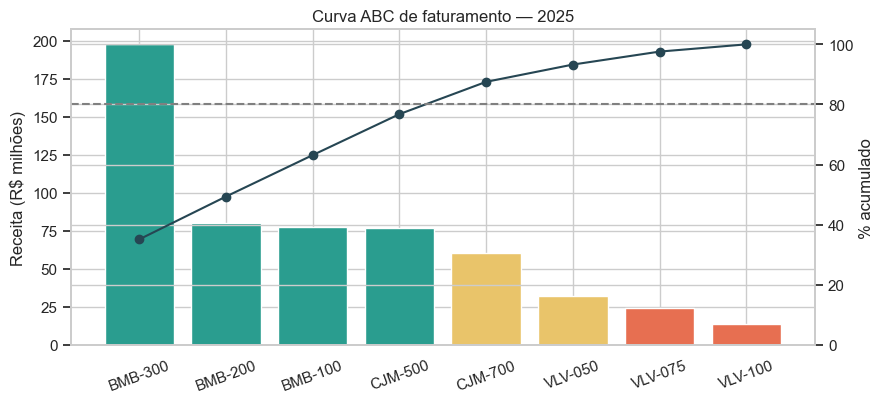

In [15]:
# Gráfico da curva ABC
fig, ax1 = plt.subplots(figsize=(9, 4.2))
cmap = {"A":"#2a9d8f","B":"#e9c46a","C":"#e76f51"}
ax1.bar(abc["sku"], abc["receita_liquida"]/1e6, color=[cmap[c] for c in abc["classe"]])
ax1.set_ylabel("Receita (R$ milhões)"); ax1.set_title("Curva ABC de faturamento — 2025")
ax2 = ax1.twinx()
ax2.plot(abc["sku"], abc["pct_acum"], color="#264653", marker="o")
ax2.axhline(80, ls="--", color="gray"); ax2.set_ylabel("% acumulado"); ax2.set_ylim(0, 105)
plt.setp(ax1.get_xticklabels(), rotation=20); plt.tight_layout(); plt.show()

### 4.6 Acurácia da previsão de demanda (MAPE)
Comparamos a previsão (ERP) com as vendas reais (ERP). MAPE menor = previsão melhor.

In [16]:
sql_prev = '''
WITH vendas AS (
  SELECT ip.produto_id, to_char(pv.data_pedido,'YYYY-MM') AS ano_mes,
         SUM(ip.quantidade) AS qtd_real
  FROM erp.item_pedido ip JOIN erp.pedido_venda pv ON pv.id = ip.pedido_id
  WHERE pv.status='FATURADO' GROUP BY 1,2)
SELECT pd.ano_mes, p.sku, pd.qtd_prevista, COALESCE(v.qtd_real,0) AS qtd_real
FROM erp.previsao_demanda pd
JOIN erp.produto p ON p.id = pd.produto_id
LEFT JOIN vendas v ON v.produto_id = pd.produto_id AND v.ano_mes = pd.ano_mes
'''
prev = pd.read_sql(sql_prev, engine)
prev = prev[prev["qtd_real"] > 0].copy()
prev["erro_abs_%"] = 100 * (prev["qtd_prevista"] - prev["qtd_real"]).abs() / prev["qtd_real"]
print(f"MAPE global = {prev['erro_abs_%'].mean():.1f}%")
mape_sku = prev.groupby("sku", as_index=False)["erro_abs_%"].mean().sort_values("erro_abs_%")
mape_sku

MAPE global = 8.4%


,sku,erro_abs_%
3,CJM-500,5.95
7,VLV-100,5.97
4,CJM-700,7.30
1,BMB-200,8.01
0,BMB-100,8.85
6,VLV-075,9.15
2,BMB-300,10.65
5,VLV-050,11.46


### 4.7 Integração ERP × MES — aderência da produção ao plano-mestre
Indicador que combina os **dois bancos** (*polyglot persistence*): o **planejado**
vem do plano-mestre (ERP) e o **produzido bom** vem dos apontamentos (MES).

In [17]:
plano = pd.read_sql(
    "SELECT p.sku, SUM(pm.qtd_planejada) AS qtd_planejada "
    "FROM erp.plano_mestre pm JOIN erp.produto p ON p.id=pm.produto_id "
    "GROUP BY p.sku", engine)
aderencia = refugo[["sku","nome","pecas_boas"]].merge(plano, on="sku")
aderencia["aderencia_%"] = 100 * aderencia["pecas_boas"] / aderencia["qtd_planejada"]
aderencia.sort_values("aderencia_%")[["nome","sku","qtd_planejada","pecas_boas","aderencia_%"]]

,nome,sku,qtd_planejada,pecas_boas,aderencia_%
2,Conjunto Pressurizador,CJM-500,20721,20484,98.86
1,Bomba Submersa 3cv,BMB-300,85755,85037,99.16
0,"Válvula Gaveta 1""",VLV-100,47375,47006,99.22
6,Bomba Centrífuga 1cv,BMB-100,72303,72255,99.93
3,Bomba Centrífuga 2cv,BMB-200,48468,48440,99.94
5,"Válvula Esfera 3/4""",VLV-075,110640,111461,100.74
4,Conjunto Booster Duplo,CJM-700,9755,9835,100.82
7,"Válvula Esfera 1/2""",VLV-050,199549,201982,101.22


## Etapa 5 — Interpretar (dado → informação → conhecimento → decisão)

Os números acima viram **recomendações de gestão**:

- **OEE global ≈ 80,7%**, logo abaixo da meta de 85%. A **qualidade é ótima
  (98,4%)**; o que derruba o indicador é **disponibilidade e performance**.
- A **Injetora 01** atinge a meta; a **Linha de Montagem 01** é o gargalo.
  → Priorizar um programa de **TPM/SMED** na Montagem e no Torno CNC 02.
- O **Pareto das paradas não tem causa única dominante** — ajustes de processo,
  falta de operador e falta de material lideram. → Ação ampla de organização do
  trabalho, não um único conserto.
- **MTBF/MTTR** dão disponibilidade inerente > 98%: as perdas **não são de
  quebra**, e sim **organizacionais** — confirma o diagnóstico das paradas.
- **Refugo** concentra-se nos conjuntos montados. → Reforçar controle dimensional
  e testes de estanqueidade.
- **Curva ABC**: poucos produtos (classe A) concentram ~77% da receita.
  → Proteger a disponibilidade dos recursos que os produzem.
- **MAPE ≈ 8,4%** com **viés de superestimação**. → Recalibrar a previsão para
  não inflar estoque e ocupação.

> **Conclusão:** o acesso direto ao banco deu autonomia para transformar o dado
> bruto em decisão fundamentada — de forma **reprodutível**: basta reexecutar
> este notebook.

In [18]:
# Encerramento — sempre fechar as conexões
client.close()
engine.dispose()
print("Conexões encerradas. POP concluído.")

Conexões encerradas. POP concluído.
